<a href="https://colab.research.google.com/github/maps-05/portfolio/blob/main/compare_behavior_between_crypto_and_airline_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: **RELATIVO, Muffle P.**

Section: **BSCPE III IE**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load Dataset

df_ethereum = pd.read_csv("https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/ethereum_price.csv", index_col='Date', parse_dates=True)
df_ethereum

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-11-09,308.64,329.45,307.06,320.88,320.88,8.932500e+08
2017-11-10,320.67,324.72,294.54,299.25,299.25,8.859860e+08
2017-11-11,298.59,319.45,298.19,314.68,314.68,8.423010e+08
2017-11-12,314.69,319.15,298.51,307.91,307.91,1.613480e+09
2017-11-13,307.02,328.42,307.02,316.72,316.72,1.041890e+09
...,...,...,...,...,...,...
2025-02-17,2663.23,2848.78,2640.18,2743.20,2743.20,2.417043e+10
2025-02-18,2743.02,2754.68,2606.90,2669.34,2669.34,2.300415e+10
2025-02-19,2669.21,2735.92,2656.38,2715.77,2715.77,1.527240e+10


In [ ]:
# Load Dataset

df_airlines = pd.read_csv("https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/airline_passengers.csv", index_col='Month', parse_dates=True)
df_airlines

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


QUESTION 1:

In [ ]:
df_ethereum['Rolling_Mean_Close'] = df_ethereum['Close'].rolling(window=30).mean()
final_mean_close = df_ethereum['Rolling_Mean_Close'].iloc[-1]

final_mean_close

2878.896

Question 2:

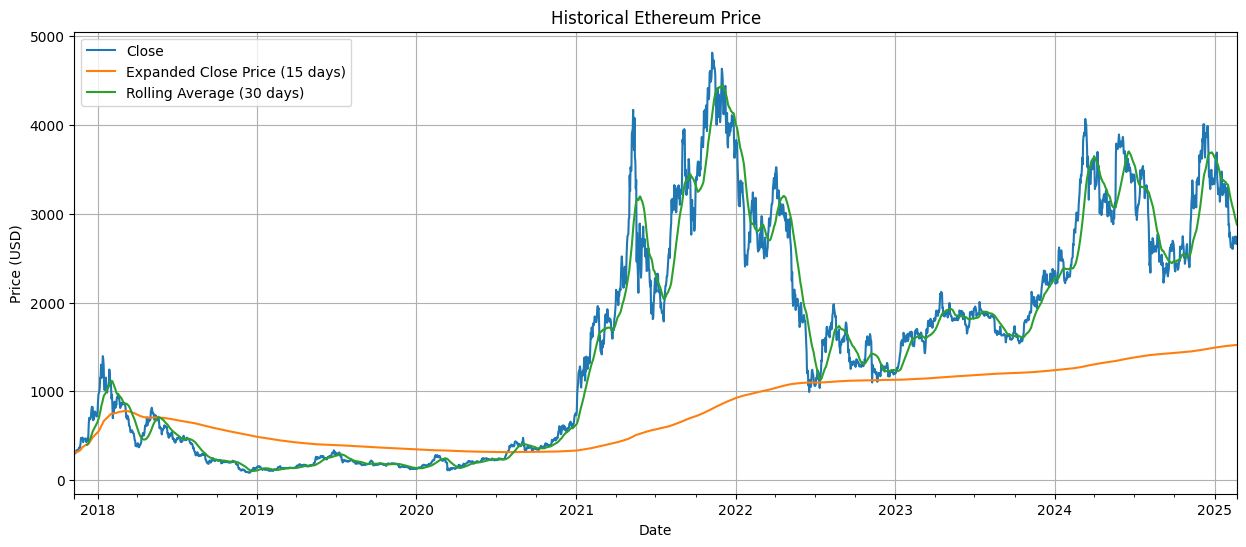

In [ ]:
df_ethereum['Expanded Close Price (15 days)'] = df_ethereum['Close'].expanding().mean()
df_ethereum['Rolling Average (30 days)'] = df_ethereum['Close'].rolling(window=30).mean()

df_ethereum[['Close', 'Expanded Close Price (15 days)', 'Rolling Average (30 days)']].plot(figsize=(15,6), title="Historical Ethereum Price", grid=True, xlabel="Date", ylabel="Price (USD)").legend(loc='upper left');

Question 3:

The Ethereum price trend shows that while short-term fluctuations occur, the overall direction becomes clearer with expanding and rolling averages, helping to identify long-term patterns.

Question 4:

In [ ]:
df_filtered = df_ethereum[(df_ethereum.index >= '2022-01-01') & (df_ethereum.index <= '2024-12-31')]

highest_price = df_filtered['Close'].max()
lowest_price = df_filtered['Close'].min()

print(f'Highest Ethereum Close Price: ${highest_price:.2f}')
print(f'Lowest Ethereum Close Price: ${lowest_price:.2f}')


Highest Ethereum Close Price: $4066.45
Lowest Ethereum Close Price: $993.64


Question 5:

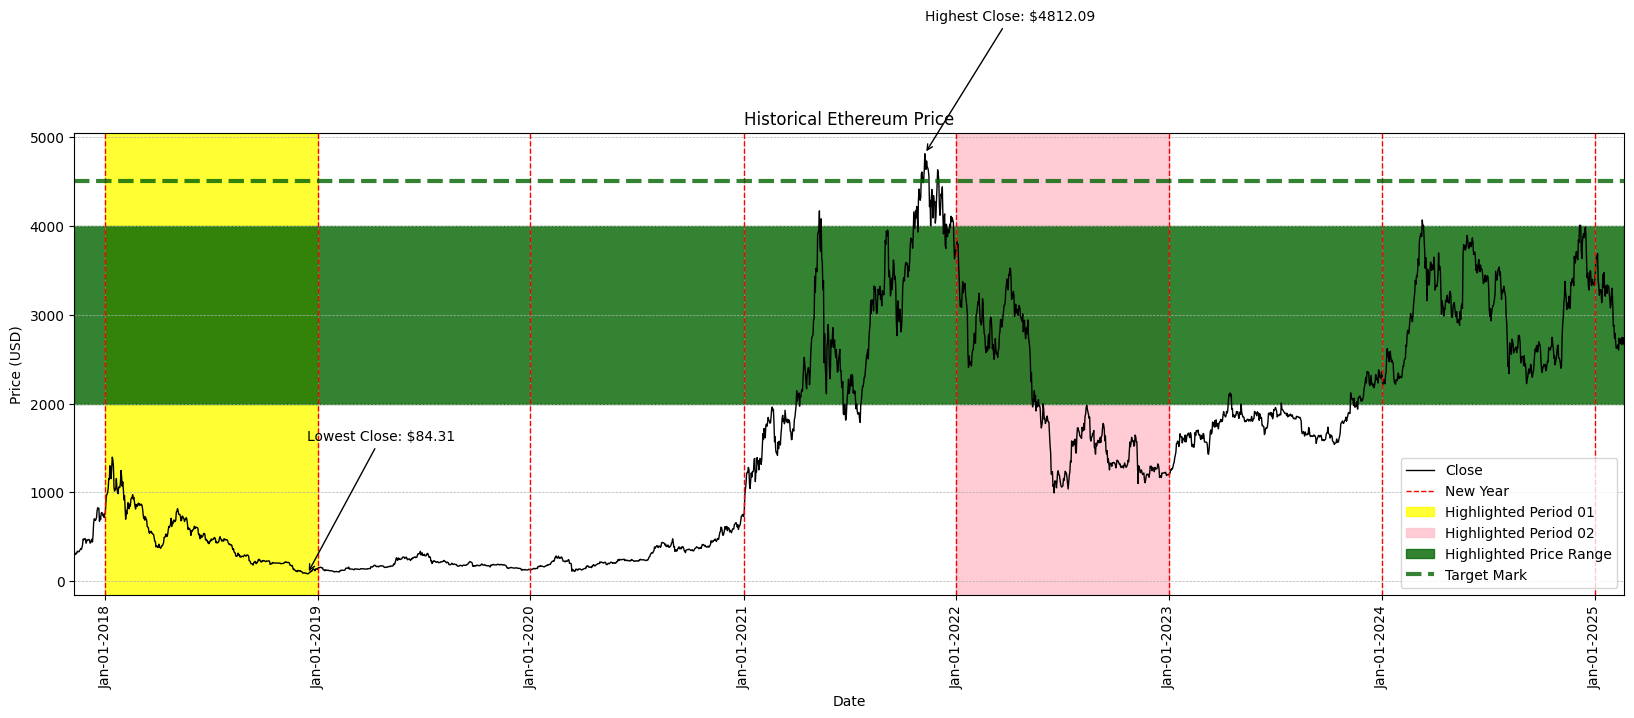

In [ ]:
df_ethereum.index = pd.to_datetime(df_ethereum.index)

highest_close = df_ethereum['Close'].max()
lowest_close = df_ethereum['Close'].min()
highest_date = df_ethereum['Close'].idxmax()
lowest_date = df_ethereum['Close'].idxmin()

target_price = 4500
highlight_range = (2000, 4000)

fig, ax = plt.subplots(figsize=(20, 6))
ax.plot(df_ethereum.index, df_ethereum['Close'], color='black', linewidth=1, label='Close')
start_year = df_ethereum.index.min().year
end_year = df_ethereum.index.max().year

for year in range(start_year + 1, end_year + 1):
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='red', linestyle='dashed', linewidth=1, label='New Year' if year == start_year + 1 else None)

ax.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2019-01-01'), color='yellow', alpha=0.8, label='Highlighted Period 01')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2023-01-01'), color='pink', alpha=0.8, label='Highlighted Period 02')

ax.axhspan(*highlight_range, color='darkgreen', alpha=0.8, label='Highlighted Price Range')

ax.axhline(y=target_price, color='darkgreen', linestyle='dashed', linewidth=3, label='Target Mark', alpha=0.8)
ax.text(df_ethereum.index[-1], target_price, '', color='darkgreen', fontsize=12, fontweight='bold', verticalalignment='bottom')

ax.annotate(f'Highest Close: ${highest_close:.2f}', xy=(highest_date, highest_close),
             xytext=(highest_date, highest_close + 1500),
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=10)
ax.annotate(f'Lowest Close: ${lowest_close:.2f}', xy=(lowest_date, lowest_close),
             xytext=(lowest_date, lowest_close + 1500),
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=10)

xticks = pd.date_range(start='2018-01-01', end='2025-01-01', freq='YS')
ax.set_xticks(xticks)
ax.set_xticklabels([date.strftime('%b-%d-%Y') for date in xticks], rotation=90)
plt.xlim(df_ethereum.index.min(), df_ethereum.index.max())

ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.set_title('Historical Ethereum Price')
ax.legend()
plt.grid(True, linestyle='dashed', linewidth=0.5)

plt.show()

In [ ]:
from statsmodels.tsa.filters.hp_filter import hpfilter

Question 6:

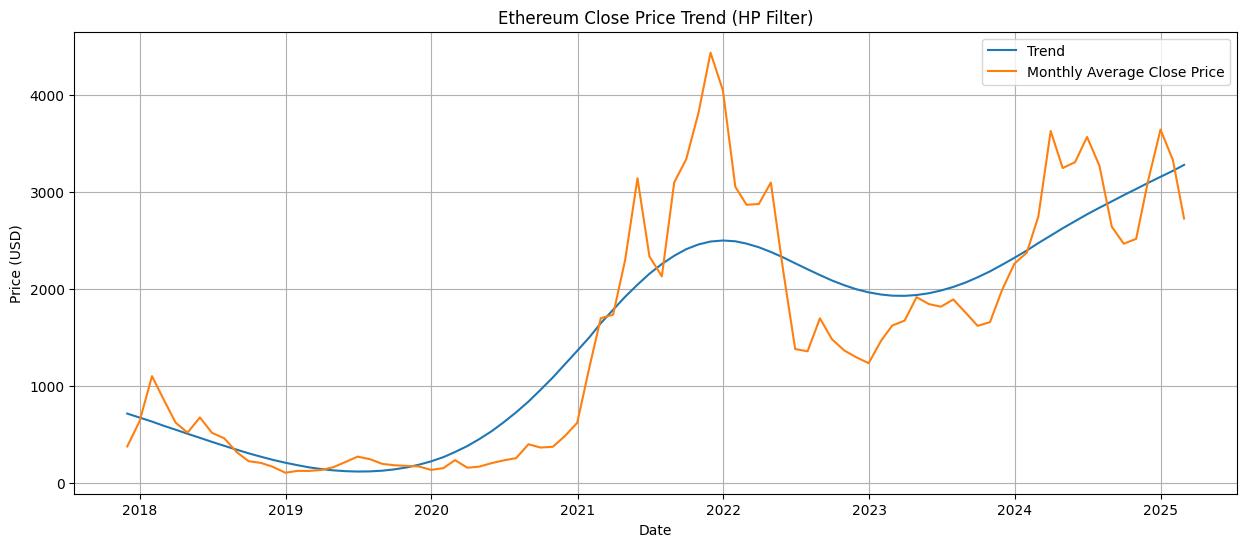

In [ ]:
monthly_end_mean = df_ethereum['Close'].resample('ME').mean()

cycle, trend = hpfilter(monthly_end_mean, lamb=1600)

plt.figure(figsize=(15, 6))
plt.plot(trend, label='Trend')
plt.plot(monthly_end_mean, label='Monthly Average Close Price')
plt.legend()
plt.title('Ethereum Close Price Trend (HP Filter)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()

Question 7:

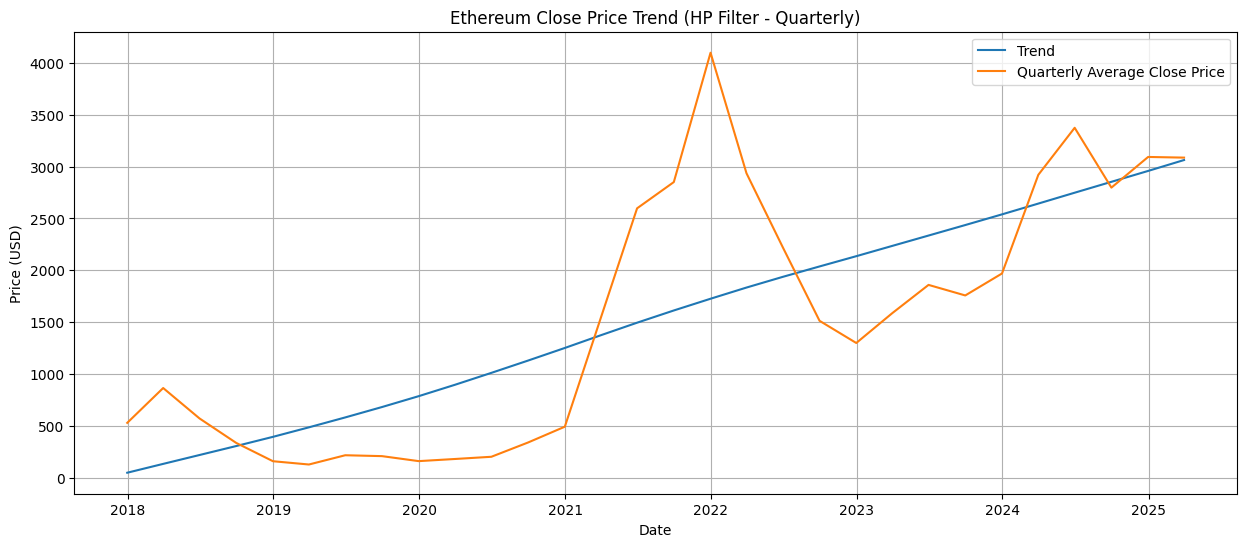

In [ ]:
quarterly_end_mean = df_ethereum['Close'].resample('QE').mean()

cycle, trend = hpfilter(quarterly_end_mean, lamb=1600)

plt.figure(figsize=(15, 6))
plt.plot(trend, label='Trend')
plt.plot(quarterly_end_mean, label='Quarterly Average Close Price')
plt.legend()
plt.title('Ethereum Close Price Trend (HP Filter - Quarterly)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.show()

Question 8:


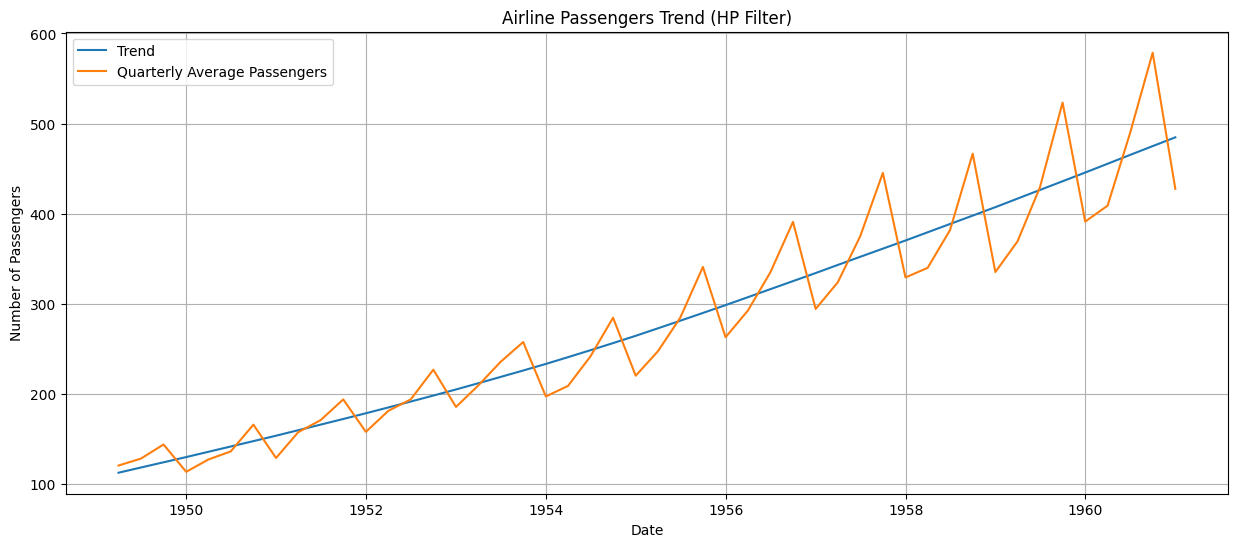

In [ ]:
quarterly_airplnes = df_airlines['Thousands of Passengers'].resample('QE').mean()

cycle, trend = hpfilter(quarterly_airplnes, lamb=1600)

plt.figure(figsize=(15, 6))
plt.plot(trend, label='Trend')
plt.plot(quarterly_airplnes, label='Quarterly Average Passengers')
plt.legend()
plt.title('Airline Passengers Trend (HP Filter)')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show()

Question 9:

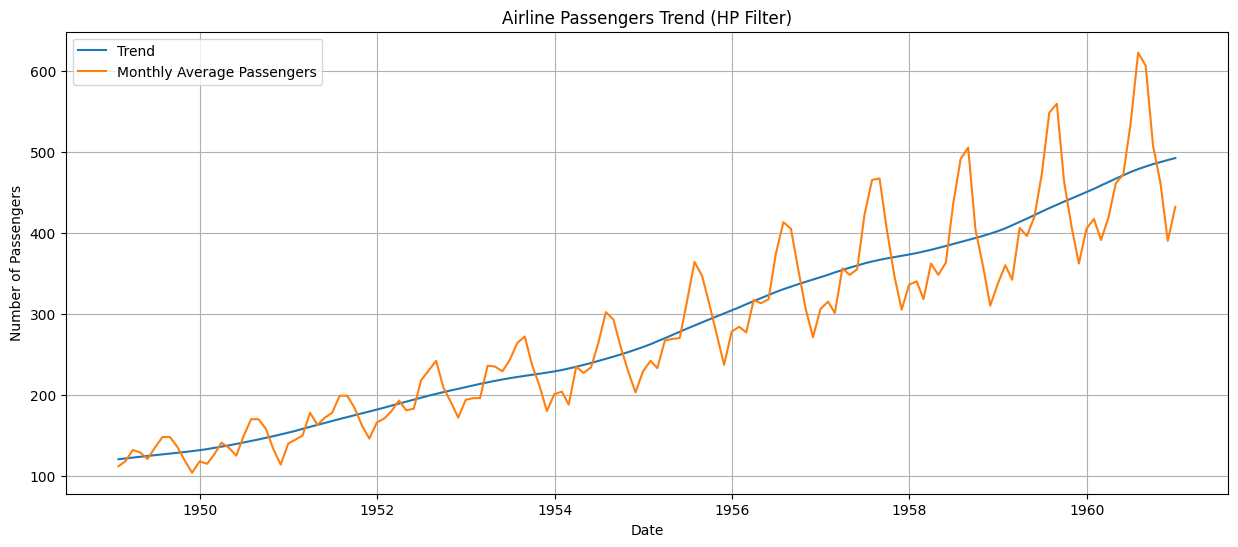

In [ ]:
monthly_airlines = df_airlines['Thousands of Passengers'].resample('ME').mean()

cycle, trend = hpfilter(monthly_airlines, lamb=1600)

plt.figure(figsize=(15, 6))
plt.plot(trend, label='Trend')
plt.plot(monthly_airlines, label='Monthly Average Passengers')
plt.legend()
plt.title('Airline Passengers Trend (HP Filter)')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show()

Question 10:

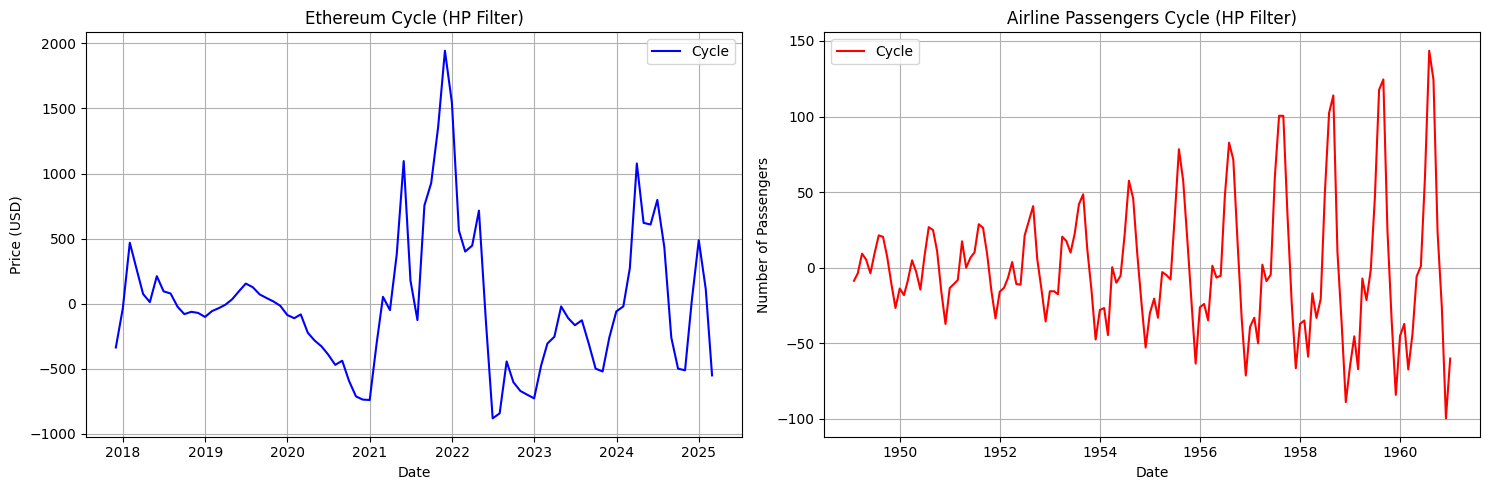

In [ ]:
monthly_et = df_ethereum['Close'].resample('ME').mean()
cycle_et, trend_et = hpfilter(monthly_et, lamb=1600)

monthly_ap = df_airlines['Thousands of Passengers'].resample('ME').mean()
cycle_ap, trend_ap = hpfilter(monthly_ap, lamb=1600)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(cycle_et, label='Cycle', color='blue')
axes[0].set_title('Ethereum Cycle (HP Filter)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(cycle_ap, label='Cycle', color='red')
axes[1].set_title('Airline Passengers Cycle (HP Filter)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Passengers')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()